In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils._statistical_relevance import *

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('physrev_noticks.mplstyle')
plt.rcParams.update({"figure.figsize": [3.25, 1.01]})
plt.rcParams['figure.dpi'] = "300"

In [2]:
# _get_pearson_table("train")

In [3]:
def _get_pearson_table(tag="train"):
    table_path = f"./analysis_results/statistical_relevance/correlation_table_{tag}.npy"
    save_path = f"./figures/statistical_relevance_{tag}.svg"


    pearson_table = np.load(table_path, allow_pickle=True)
    
    pd_pearson = pd.DataFrame(dict(pearson_table.tolist()))
    heatmap_data = pd_pearson.pivot(columns='label', index='opts', values='pearsonr')

    heatmap_data.columns = ["BM", "SubATTM", "SubCTRW", "SubFBM", "SubSBM", "SupFBM", "SupLW", "SupSBM"]
    heatmap_data = heatmap_data[["SubFBM", 
                                "SupFBM", "SupLW", 
                                "SubCTRW", "SubATTM", 
                                "SubSBM", "SupSBM", "BM"]] # reindex by clustering
    # Define the colormap with a wide plateau around 0
    colors = [(0, 0, 1), (1, 1, 1), ( 1, 1, 1), (1, 1, 1), (1, 0, 0)]  # Blue to Gray to White to Gray to Red
    n_bins = 100  # Number of bins
    cmap_name = "custom_cmap"
    color_stops = [0.0, 0.85 / 2, 0.5, 1.15 / 2, 1.0]
    custom_cmap = LinearSegmentedColormap.from_list(cmap_name, list(zip(color_stops, colors)), N=n_bins)
    norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)
    ax = sns.heatmap(heatmap_data, annot=True, vmin=-0.4, vmax=0.4, cmap=custom_cmap, norm=norm, linewidths=0.1,
                linecolor='white', fmt='.2f', cbar=True, annot_kws={"size": 6})
    # plt.title("Grad-CAM pearson correlation with statistical property")
    # ax.set_xticklabels(["BM", "SubATTM", "SubCTRW", "SubFBM", "SubSBM", "SupFBM", "SupLW", "SupSBM"])
    # in making, label sorted in different way.
    ax.set_yticklabels(ax.get_yticklabels(), rotation="horizontal", horizontalalignment="center")
    ax.set_yticklabels(["AC", "CS", "SG", "VD"])

    for i in range(1, len(heatmap_data.columns)):
        if i in [2,4,6,7]:
            continue
        ax.axvline(i, color='black', linestyle='-', linewidth=1.2)

    plt.xlabel("")
    plt.ylabel("")
    plt.savefig(save_path)
    plt.show()

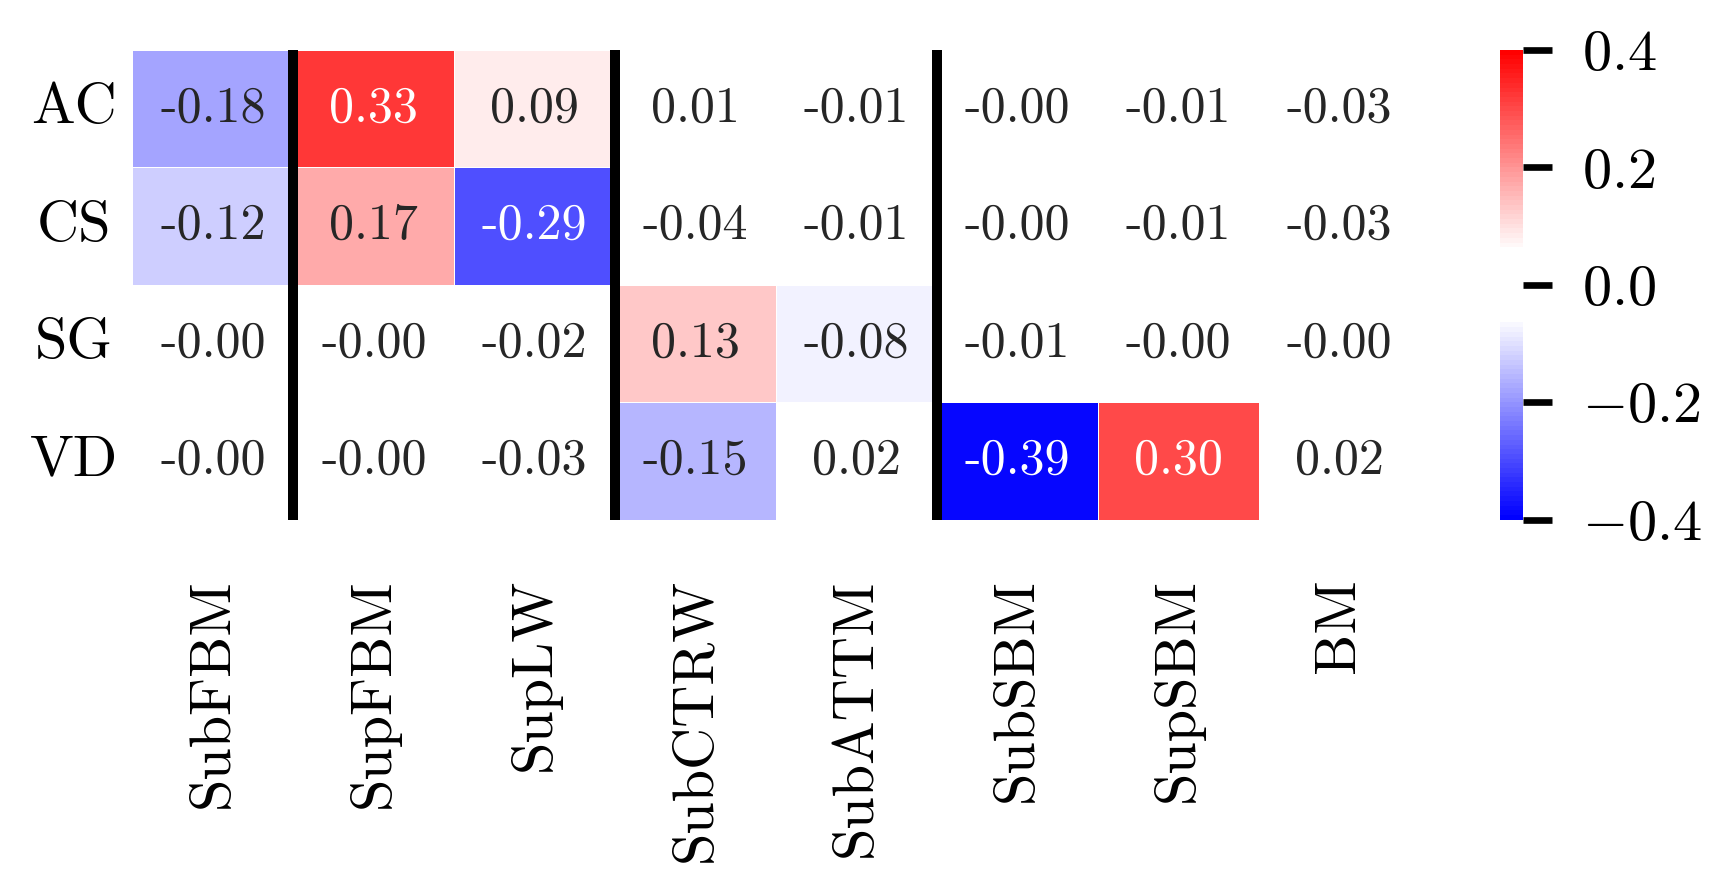

In [4]:
_ = _get_pearson_table("train")

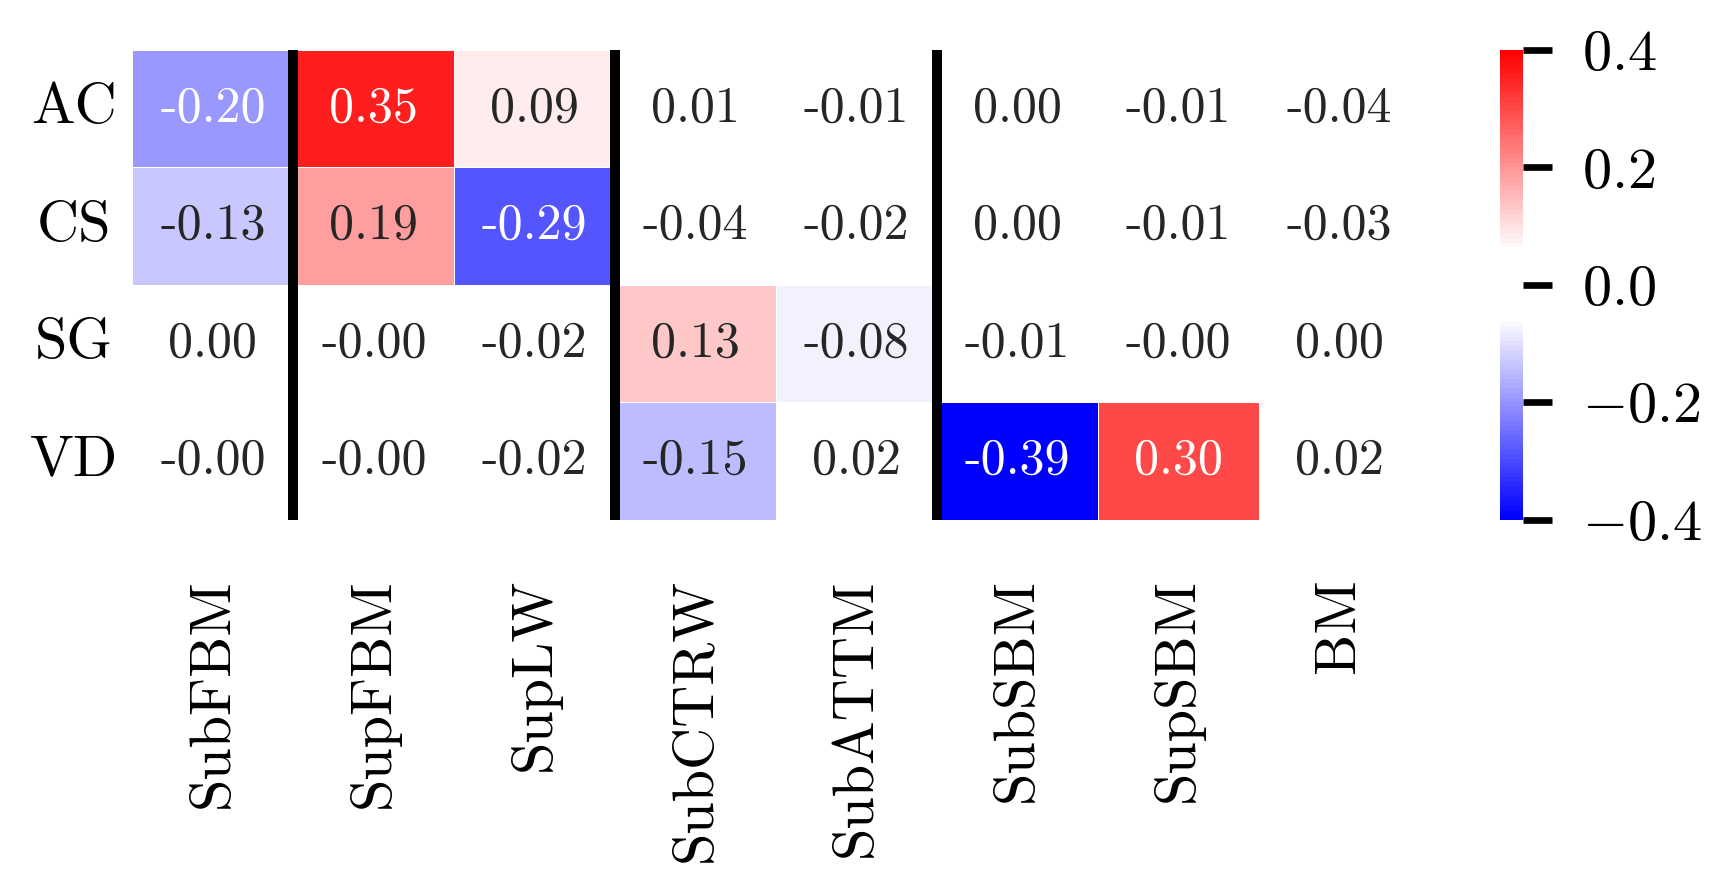

In [5]:
_ = _get_pearson_table("test")